# Practical Application III: Comparing Classifiers

**Overview**: In this practical application, your goal is to compare the performance of the classifiers we encountered in this section, namely K Nearest Neighbor, Logistic Regression, Decision Trees, and Support Vector Machines.  We will utilize a dataset related to marketing bank products over the telephone.  



### Getting Started

Our dataset comes from the UCI Machine Learning repository [link](https://archive.ics.uci.edu/ml/datasets/bank+marketing).  The data is from a Portugese banking institution and is a collection of the results of multiple marketing campaigns.  We will make use of the article accompanying the dataset [here](CRISP-DM-BANK.pdf) for more information on the data and features.



### Problem 1: Understanding the Data

To gain a better understanding of the data, please read the information provided in the UCI link above, and examine the **Materials and Methods** section of the paper.  How many marketing campaigns does this data represent?

The dataset represents multiple direct marketing campaigns conducted by a Portuguese banking institution over time. According to the UCI description and the Materials and Methods section of the accompanying paper, the data aggregates customer interactions from both current and past campaigns rather than focusing on a single campaign.

While the dataset does not specify an exact number of distinct campaigns, it includes variables such as campaign (number of contacts during the current campaign) and previous along with poutcome (information from prior campaigns). This indicates that the dataset captures results from multiple campaigns across different time periods, providing a comprehensive view of the bank’s marketing efforts.

### Problem 2: Read in the Data

Use pandas to read in the dataset `bank-additional-full.csv` and assign to a meaningful variable name.

In [231]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import classification_report
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import auc as skl_auc

In [113]:
df = pd.read_csv('data/bank-additional-full.csv', sep = ';')

In [114]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


### Problem 3: Understanding the Features


Examine the data description below, and determine if any of the features are missing values or need to be coerced to a different data type.


```
Input variables:
# bank client data:
1 - age (numeric)
2 - job : type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')
3 - marital : marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)
4 - education (categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')
5 - default: has credit in default? (categorical: 'no','yes','unknown')
6 - housing: has housing loan? (categorical: 'no','yes','unknown')
7 - loan: has personal loan? (categorical: 'no','yes','unknown')
# related with the last contact of the current campaign:
8 - contact: contact communication type (categorical: 'cellular','telephone')
9 - month: last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')
10 - day_of_week: last contact day of the week (categorical: 'mon','tue','wed','thu','fri')
11 - duration: last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.
# other attributes:
12 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
13 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)
14 - previous: number of contacts performed before this campaign and for this client (numeric)
15 - poutcome: outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success')
# social and economic context attributes
16 - emp.var.rate: employment variation rate - quarterly indicator (numeric)
17 - cons.price.idx: consumer price index - monthly indicator (numeric)
18 - cons.conf.idx: consumer confidence index - monthly indicator (numeric)
19 - euribor3m: euribor 3 month rate - daily indicator (numeric)
20 - nr.employed: number of employees - quarterly indicator (numeric)

Output variable (desired target):
21 - y - has the client subscribed a term deposit? (binary: 'yes','no')
```



In [115]:
df.shape

(41188, 21)

In [116]:
df.isna().any()

age               False
job               False
marital           False
education         False
default           False
housing           False
loan              False
contact           False
month             False
day_of_week       False
duration          False
campaign          False
pdays             False
previous          False
poutcome          False
emp.var.rate      False
cons.price.idx    False
cons.conf.idx     False
euribor3m         False
nr.employed       False
y                 False
dtype: bool

In [117]:
val = df.duplicated().sum()
print(int(val))

12


In [118]:
df.drop_duplicates(inplace = True)

In [119]:
df.shape

(41176, 21)

In [120]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41176.00000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000
mean,40.02380,258.315815,2.567879,962.464810,0.173013,0.081922,93.575720,-40.502863,3.621293,5167.034870
std,10.42068,259.305321,2.770318,186.937102,0.494964,1.570883,0.578839,4.627860,1.734437,72.251364
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


array([[<Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'duration'}>,
        <Axes: title={'center': 'campaign'}>],
       [<Axes: title={'center': 'pdays'}>,
        <Axes: title={'center': 'previous'}>,
        <Axes: title={'center': 'emp.var.rate'}>],
       [<Axes: title={'center': 'cons.price.idx'}>,
        <Axes: title={'center': 'cons.conf.idx'}>,
        <Axes: title={'center': 'euribor3m'}>],
       [<Axes: title={'center': 'nr.employed'}>, <Axes: >, <Axes: >]],
      dtype=object)

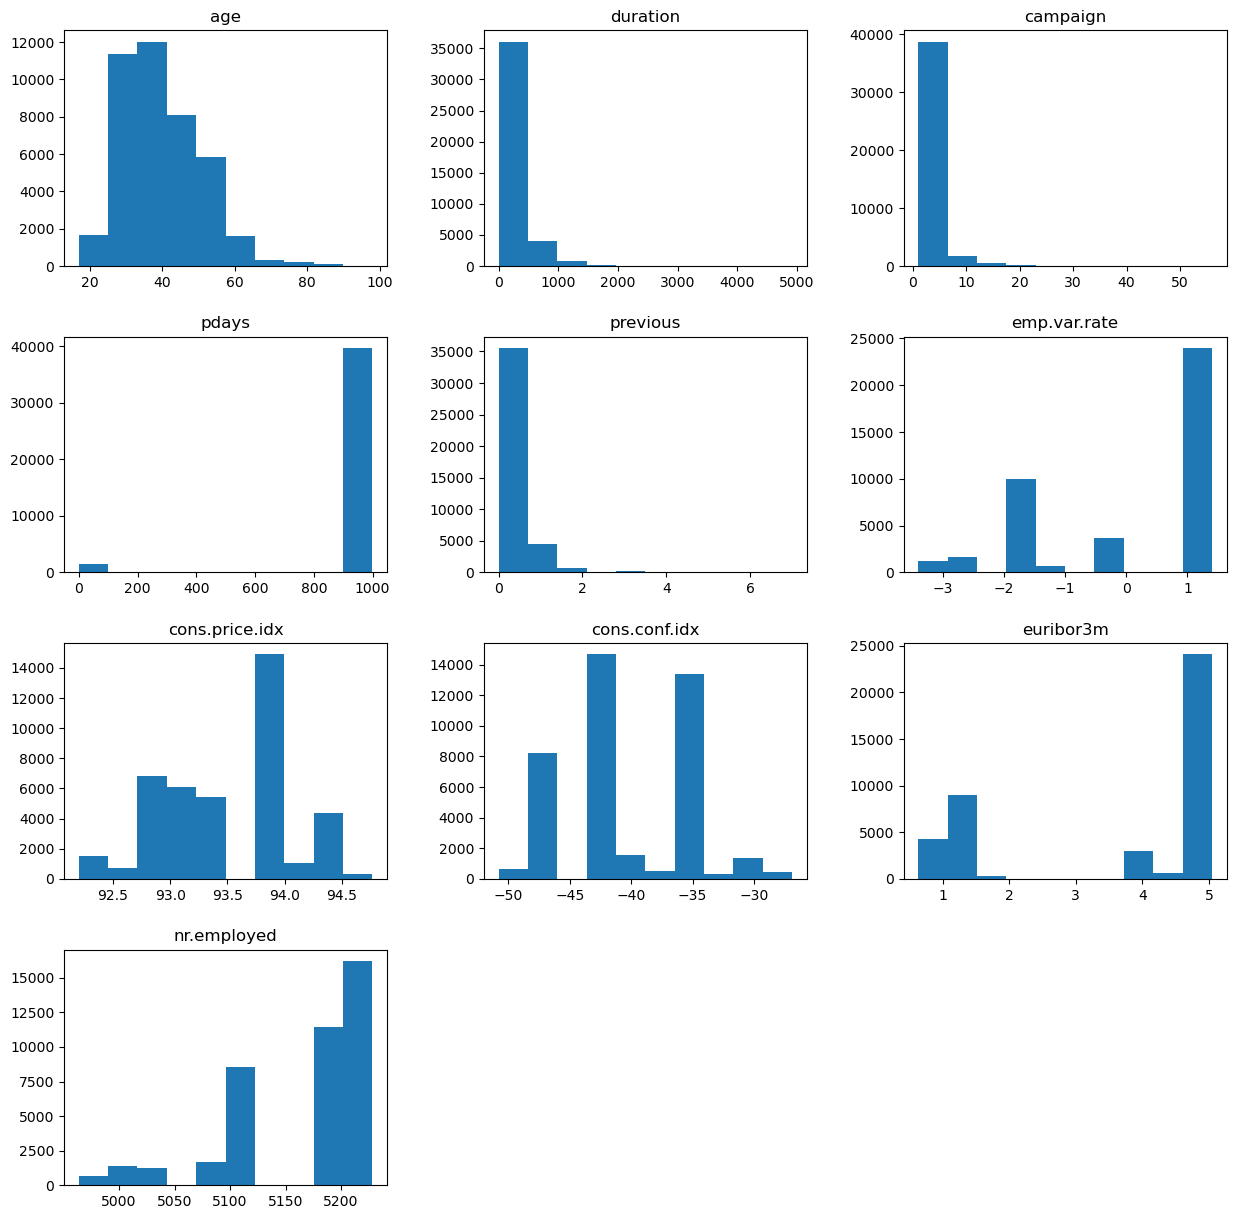

In [121]:
df.hist(figsize=(15,15), grid=False)

In [122]:
cat_list = df.select_dtypes('object').columns.tolist()
cat_list

['job',
 'marital',
 'education',
 'default',
 'housing',
 'loan',
 'contact',
 'month',
 'day_of_week',
 'poutcome',
 'y']

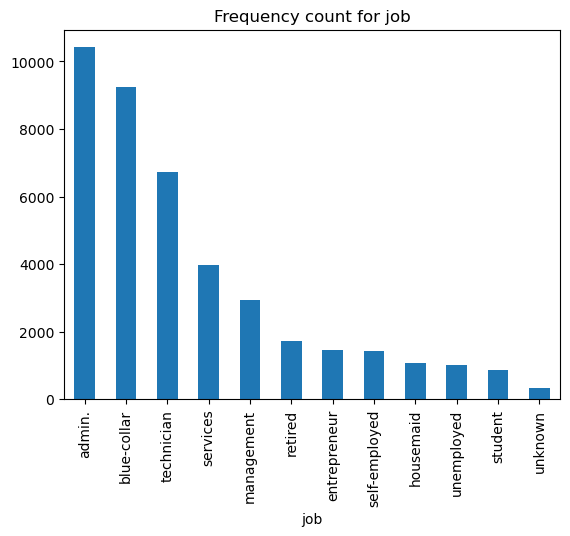

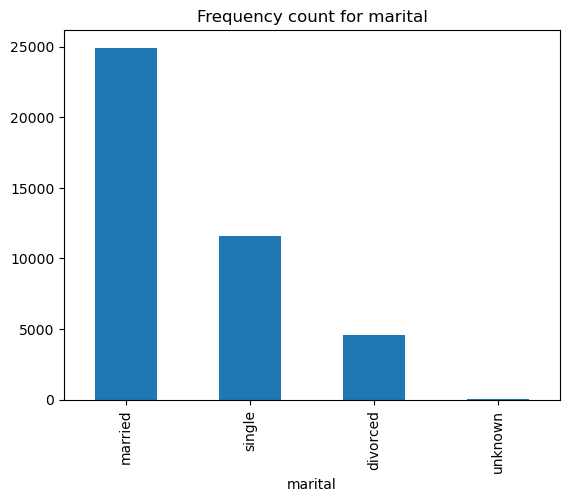

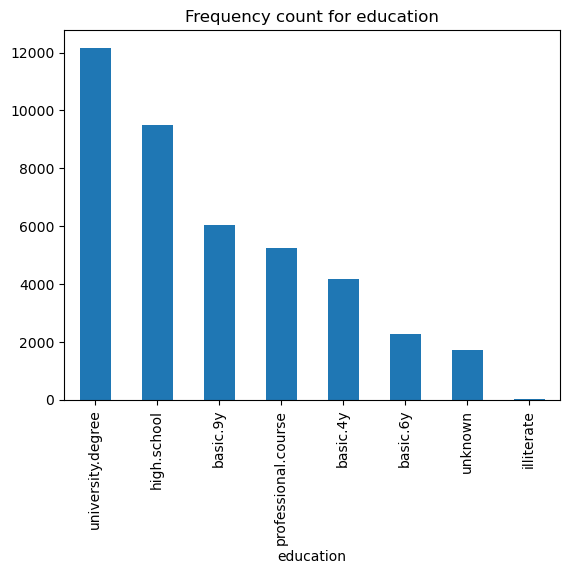

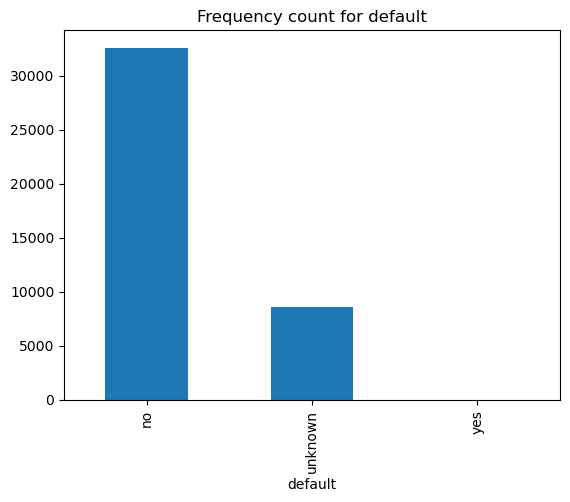

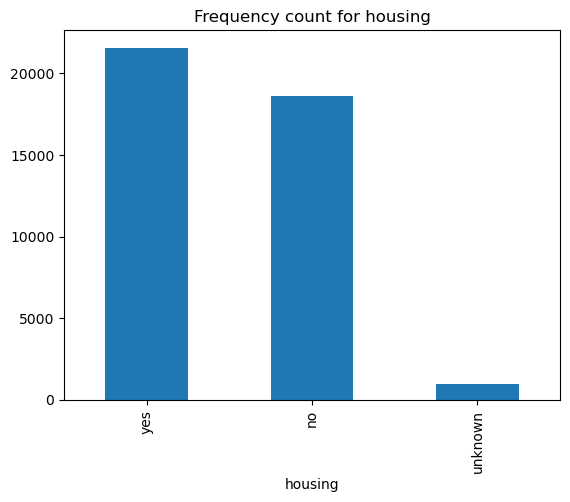

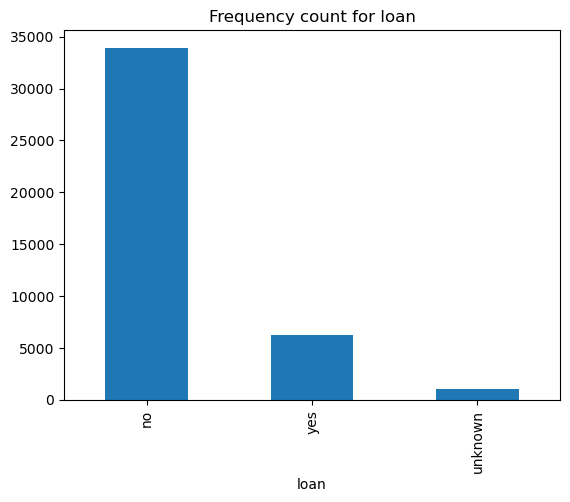

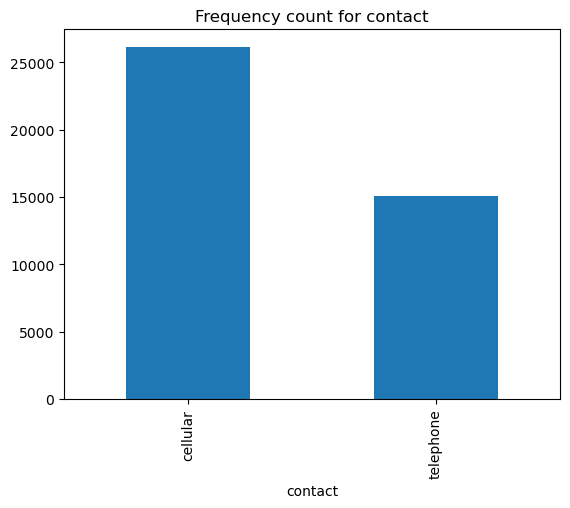

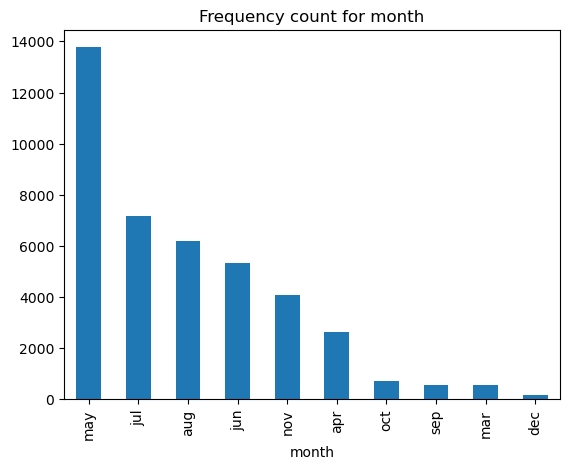

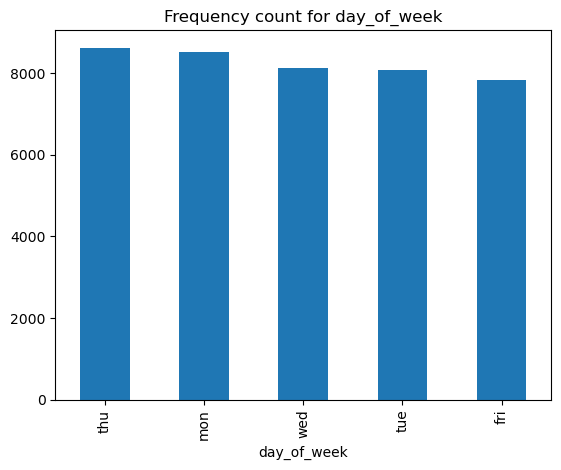

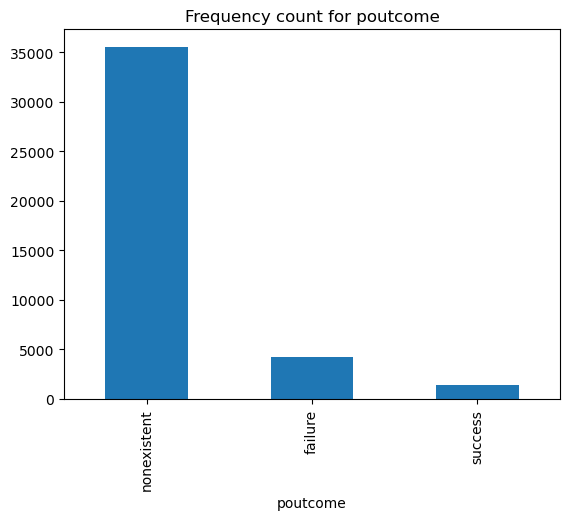

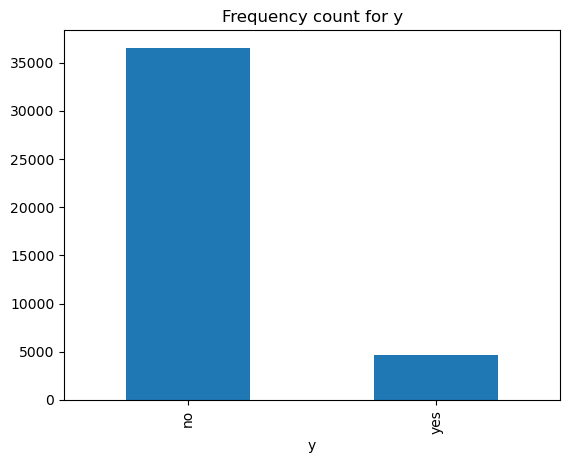

In [123]:
for cat in cat_list:
    df[cat].value_counts().plot(kind='bar', title=f'Frequency count for {cat}')
    plt.show()

In [124]:
df['y'] = df['y'].map({'no': 0, 'yes': 1})

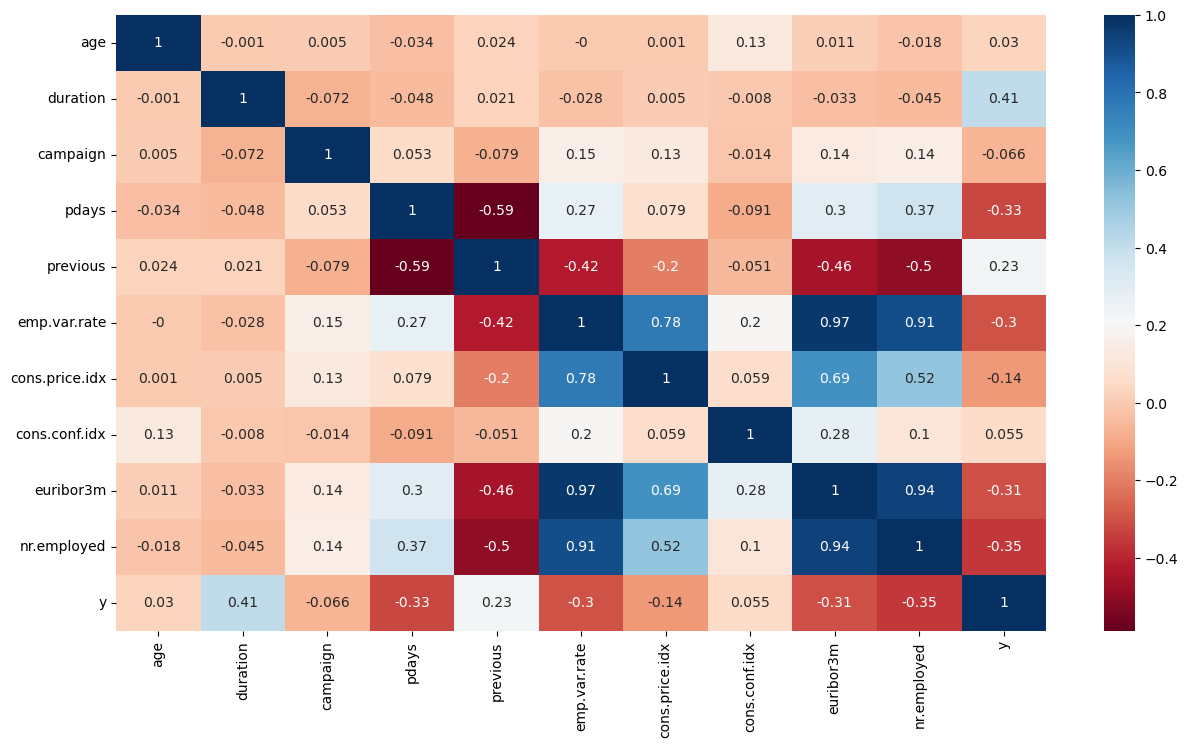

In [125]:
#bi-variate analysis
corr = df.corr(numeric_only = True).round(3)
plt.figure(figsize=(15,8))
sns.heatmap(corr, annot = True, cmap='RdBu');

In [126]:
df.groupby('y')['duration'].mean().round()

y
0    221.0
1    553.0
Name: duration, dtype: float64

In [127]:
df.groupby('y')['duration'].median().round()

y
0    164.0
1    449.0
Name: duration, dtype: float64

In [128]:
pd.crosstab(df['y'], df['nr.employed'], normalize=True).round(2)

nr.employed,4963.6,4991.6,5008.7,5017.5,5023.5,5076.2,5099.1,5176.3,5191.0,5195.8,5228.1
y,,,,,,,,,,,
0,0.01,0.01,0.01,0.01,0.0,0.03,0.18,0.0,0.18,0.08,0.37
1,0.01,0.01,0.01,0.01,0.0,0.01,0.03,0.0,0.01,0.01,0.02


<Axes: title={'center': 'Avg Acceptance across Months'}, xlabel='month'>

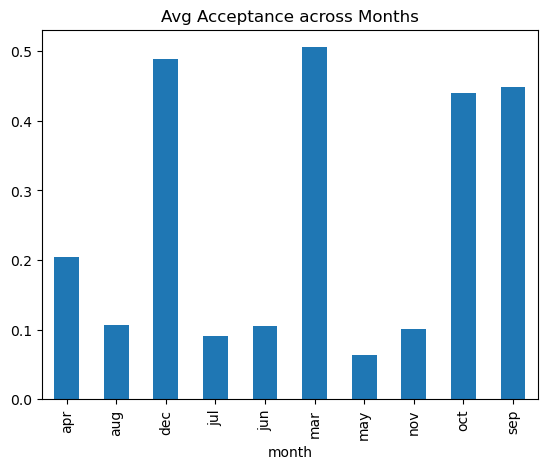

In [129]:
df.groupby('month')['y'].mean().plot(kind='bar', title='Avg Acceptance across Months')

In [130]:
df['month'] = df['month'].map({'apr': 4, 'aug': 8, 'dec':12, 'jul':7, 'jun':6, 'mar':3, 'may':5, 'nov':11, 'oct':10, 'sep':9})

### Problem 4: Understanding the Task

After examining the description and data, your goal now is to clearly state the *Business Objective* of the task.  State the objective below.

In [133]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 41176 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41176 non-null  int64  
 1   job             41176 non-null  object 
 2   marital         41176 non-null  object 
 3   education       41176 non-null  object 
 4   default         41176 non-null  object 
 5   housing         41176 non-null  object 
 6   loan            41176 non-null  object 
 7   contact         41176 non-null  object 
 8   month           41176 non-null  int64  
 9   day_of_week     41176 non-null  object 
 10  duration        41176 non-null  int64  
 11  campaign        41176 non-null  int64  
 12  pdays           41176 non-null  int64  
 13  previous        41176 non-null  int64  
 14  poutcome        41176 non-null  object 
 15  emp.var.rate    41176 non-null  float64
 16  cons.price.idx  41176 non-null  float64
 17  cons.conf.idx   41176 non-null  floa

#### Business Objective 
The primary business objective is to design an effective direct marketing strategy that increases the likelihood of customers subscribing to a term deposit offered by the bank.

A term deposit is a financial product in which a customer deposits money for a fixed duration and, in return, earns a higher interest rate compared to a standard savings account.

Traditional mass marketing campaigns often result in low conversion rates. By analyzing customer characteristics along with past campaign outcomes, the bank can better identify and target individuals who are more likely to subscribe, thereby improving overall campaign effectiveness.

### Problem 5: Engineering Features

Now that you understand your business objective, we will build a basic model to get started.  Before we can do this, we must work to encode the data.  Using just the bank information features, prepare the features and target column for modeling with appropriate encoding and transformations.

In [132]:
# Display counts of categorical values with a count of each

def count_categorical_values(df):
  for column in df.select_dtypes(include=['object']):
    print(f"{column}:")
    print(df[column].value_counts())
    print()

count_categorical_values(df)

job:
job
admin.           10419
blue-collar       9253
technician        6739
services          3967
management        2924
retired           1718
entrepreneur      1456
self-employed     1421
housemaid         1060
unemployed        1014
student            875
unknown            330
Name: count, dtype: int64

marital:
marital
married     24921
single      11564
divorced     4611
unknown        80
Name: count, dtype: int64

education:
education
university.degree      12164
high.school             9512
basic.9y                6045
professional.course     5240
basic.4y                4176
basic.6y                2291
unknown                 1730
illiterate                18
Name: count, dtype: int64

default:
default
no         32577
unknown     8596
yes            3
Name: count, dtype: int64

housing:
housing
yes        21571
no         18615
unknown      990
Name: count, dtype: int64

loan:
loan
no         33938
yes         6248
unknown      990
Name: count, dtype: int64

contact:
cont

In [134]:
# Convert categorical columns to numerical values for modeling

df2 = pd.get_dummies(df, drop_first=True)

df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,5,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
1,57,services,married,high.school,unknown,no,no,telephone,5,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
2,37,services,married,high.school,no,yes,no,telephone,5,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
3,40,admin.,married,basic.6y,no,no,no,telephone,5,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
4,56,services,married,high.school,no,no,yes,telephone,5,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0


### Problem 6: Train/Test Split

With your data prepared, split it into a train and test set.

In [135]:
X = df2.drop(columns = 'y')
y = df2['y']

# train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=2)

print('X_train:', X_train.shape)
print('y_train:', y_train.shape)

print('\n')

print('X_test:', X_test.shape)
print('y_test:', y_test.shape)

display(X_train.head())
display(y_train.head())

X_train: (28823, 45)
y_train: (28823,)


X_test: (12353, 45)
y_test: (12353,)


,age,month,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,...,housing_yes,loan_unknown,loan_yes,contact_telephone,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_nonexistent,poutcome_success
39478,75,4,162,1,6,2,-1.8,93.749,-34.6,0.642,...,False,False,False,True,False,False,True,False,False,True
28422,50,4,339,1,999,0,-1.8,93.075,-47.1,1.435,...,False,False,False,False,False,True,False,False,True,False
28808,28,4,71,2,999,1,-1.8,93.075,-47.1,1.410,...,False,True,False,False,False,True,False,False,False,False
14844,31,7,45,1,999,0,1.4,93.918,-42.7,4.957,...,True,False,True,False,False,False,False,True,True,False
39320,59,3,254,2,999,0,-1.8,93.369,-34.8,0.639,...,True,False,False,False,True,False,False,False,True,False


39478    1
28422    0
28808    0
14844    0
39320    1
Name: y, dtype: int64

In [136]:
X_train.select_dtypes(['int', 'float']).head()

,age,month,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
39478,75,4,162,1,6,2,-1.8,93.749,-34.6,0.642,5008.7
28422,50,4,339,1,999,0,-1.8,93.075,-47.1,1.435,5099.1
28808,28,4,71,2,999,1,-1.8,93.075,-47.1,1.410,5099.1
14844,31,7,45,1,999,0,1.4,93.918,-42.7,4.957,5228.1
39320,59,3,254,2,999,0,-1.8,93.369,-34.8,0.639,5008.7


In [137]:
to_be_scaled_columns = ['age', 'month', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 
                        'euribor3m', 'nr.employed']

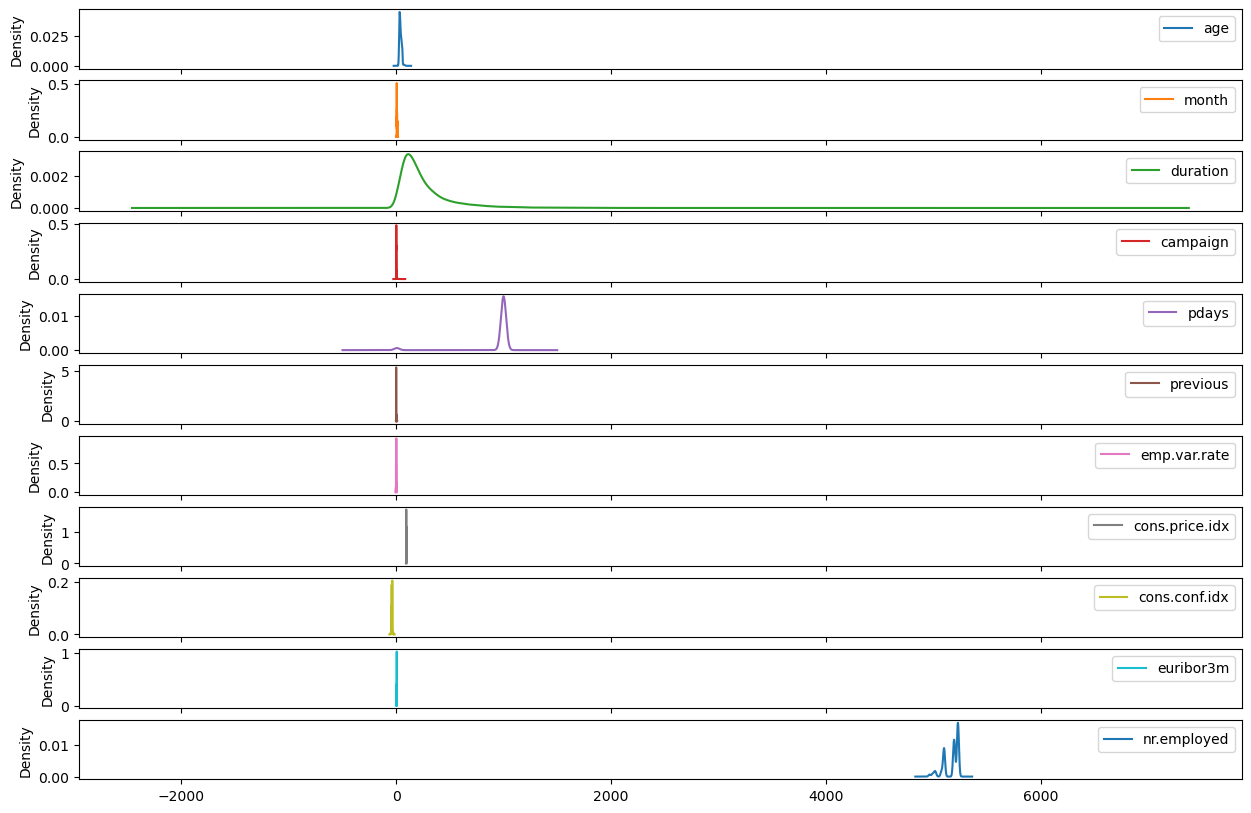

In [138]:
X_train[to_be_scaled_columns].plot(kind = 'kde', subplots = True, figsize=(15,10));

In [139]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train[to_be_scaled_columns] = scaler.fit_transform(X_train[to_be_scaled_columns])
X_test[to_be_scaled_columns] = scaler.transform(X_test[to_be_scaled_columns])


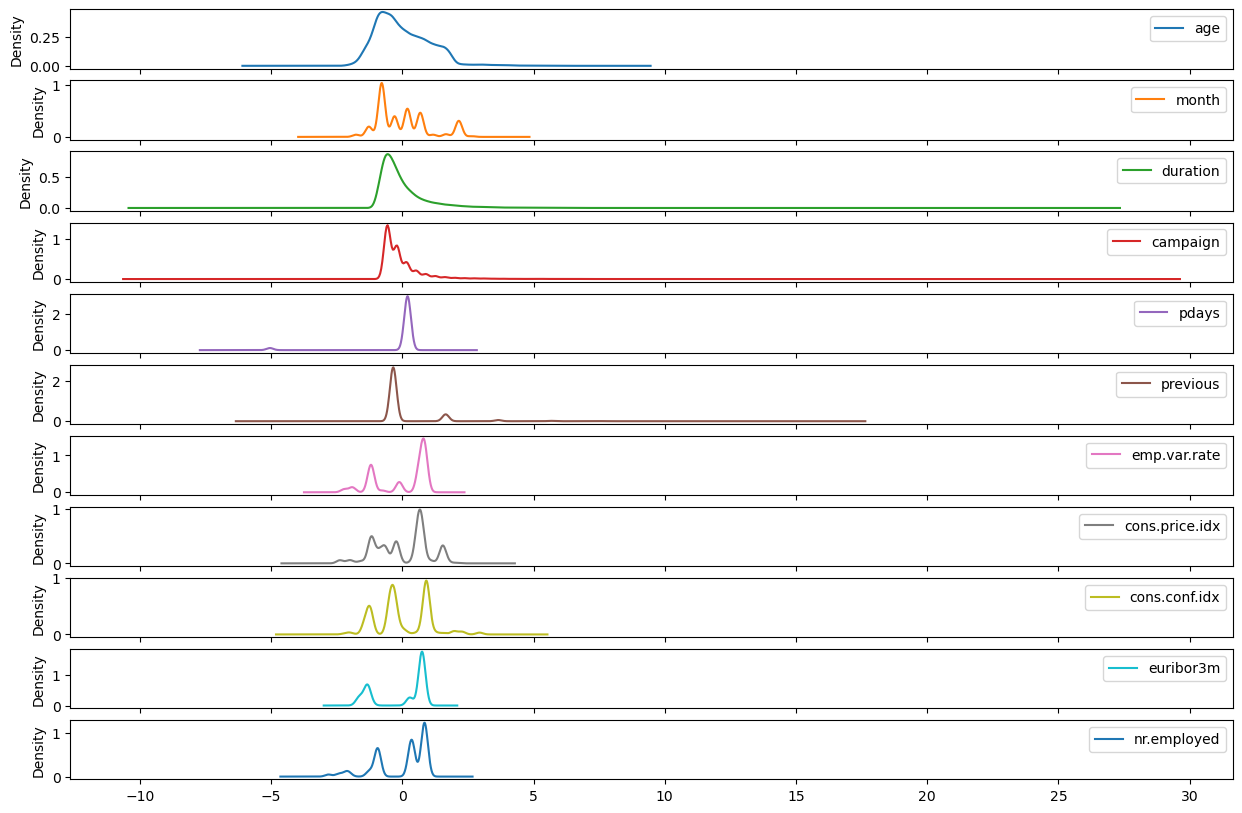

In [140]:
X_train[to_be_scaled_columns].plot(kind = 'kde', subplots = True, figsize=(15,10));

In [141]:
# Is scaler worked?
X_train[to_be_scaled_columns].agg(['mean', 'std']).round(1)

,age,month,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
mean,-0.0,0.0,0.0,0.0,-0.0,-0.0,-0.0,-0.0,0.0,0.0,-0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


### Problem 7: A Baseline Model

Before we build our first model, we want to establish a baseline.  What is the baseline performance that our classifier should aim to beat?

In [159]:
def plot_confusion_matrix(model, X, y, title, cmap='Blues'):
    #generate cm:
    cm = confusion_matrix(y, model.predict(X), labels = model.classes_)

    #display
    disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = model.classes_)

    #show plot
    disp.plot(cmap=cmap)
    disp.ax_.set_title(title)
    plt.show()

In [160]:
dummy = DummyClassifier()

In [161]:
dummy.fit(X_train, y_train)

,"strategy strategy: {""most_frequent"", ""prior"", ""stratified"", ""uniform"", ""constant""}, default=""prior""Strategy to use to generate predictions.* ""most_frequent"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit`. The `predict_proba` method returns the matching one-hot encoded vector.* ""prior"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit` (like ""most_frequent""). ``predict_proba`` always returns the empirical class distribution of `y` also known as the empirical class prior distribution.* ""stratified"": the `predict_proba` method randomly samples one-hot vectors from a multinomial distribution parametrized by the empirical class prior probabilities. The `predict` method returns the class label which got probability one in the one-hot vector of `predict_proba`. Each sampled row of both methods is therefore independent and identically distributed.* ""uniform"": generates predictions uniformly at random from the list of unique classes observed in `y`, i.e. each class has equal probability.* ""constant"": always predicts a constant label that is provided by the user. This is useful for metrics that evaluate a non-majority class. .. versionchanged:: 0.24 The default value of `strategy` has changed to ""prior"" in version 0.24.",'prior'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness to generate the predictions when``strategy='stratified'`` or ``strategy='uniform'``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"constant constant: int or str or array-like of shape (n_outputs,), default=NoneThe explicit constant as predicted by the ""constant"" strategy. Thisparameter is useful only for the ""constant"" strategy.",None


In [162]:
print('The accuracy of the model for Train is {:.2f}'.format(dummy.score(X_train, y_train)))

The accuracy of the model for Train is 0.89


In [163]:
print('The accuracy of the model for Test is {:.2f}'.format(dummy.score(X_test, y_test)))

The accuracy of the model for Test is 0.89


### Problem 8: A Simple Model

Use Logistic Regression to build a basic model on your data.  

In [164]:
lr = LogisticRegression()

start = time.time()
lr.fit(X_train, y_train)
lr_time = time.time() - start
lr_time
lr

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

### Problem 9: Score the Model

What is the accuracy of your model?

In [165]:
accuracy_lr_train = lr.score(X_train, y_train)
accuracy_lr_test = lr.score(X_test, y_test)

print('The accuracy of the model for Train is {:.2f}'.format(accuracy_lr_train))
print('The accuracy of the model for Test is {:.2f}'.format(accuracy_lr_test))

The accuracy of the model for Train is 0.91
The accuracy of the model for Test is 0.91


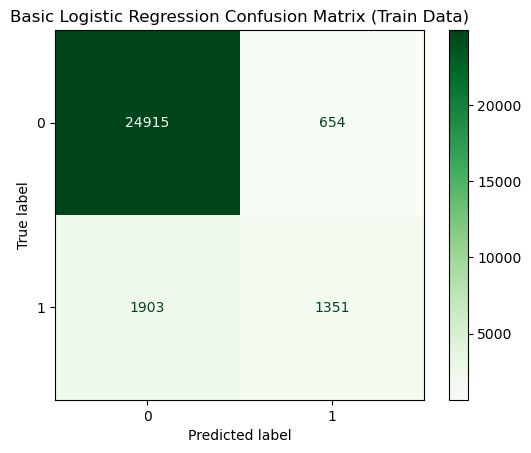

In [176]:
plot_confusion_matrix(lr, X_train, y_train, 'Basic Logistic Regression Confusion Matrix (Train Data)', cmap='Greens')

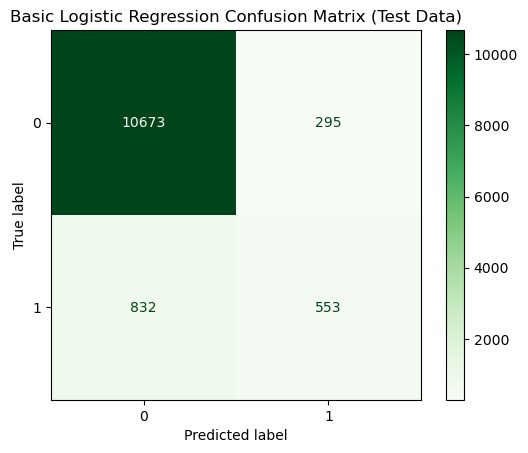

In [177]:
plot_confusion_matrix(lr, X_test, y_test, 'Basic Logistic Regression Confusion Matrix (Test Data)', cmap='Greens')

In [178]:
print ('Accuracy of LR: ', accuracy_score(y_test, lr.predict(X_test)))
print ('Recall of LR: ', recall_score(y_test, lr.predict(X_test)))
print ('Precision of LR: ', precision_score(y_test, lr.predict(X_test)))

Accuracy of LR:  0.9087671011090424
Recall of LR:  0.3992779783393502
Precision of LR:  0.652122641509434


In [179]:
y_pred = lr.predict(X_test)
target_names = ['no', 'yes']
print(classification_report(y_test, y_pred, target_names= target_names))

              precision    recall  f1-score   support

          no       0.93      0.97      0.95     10968
         yes       0.65      0.40      0.50      1385

    accuracy                           0.91     12353
   macro avg       0.79      0.69      0.72     12353
weighted avg       0.90      0.91      0.90     12353



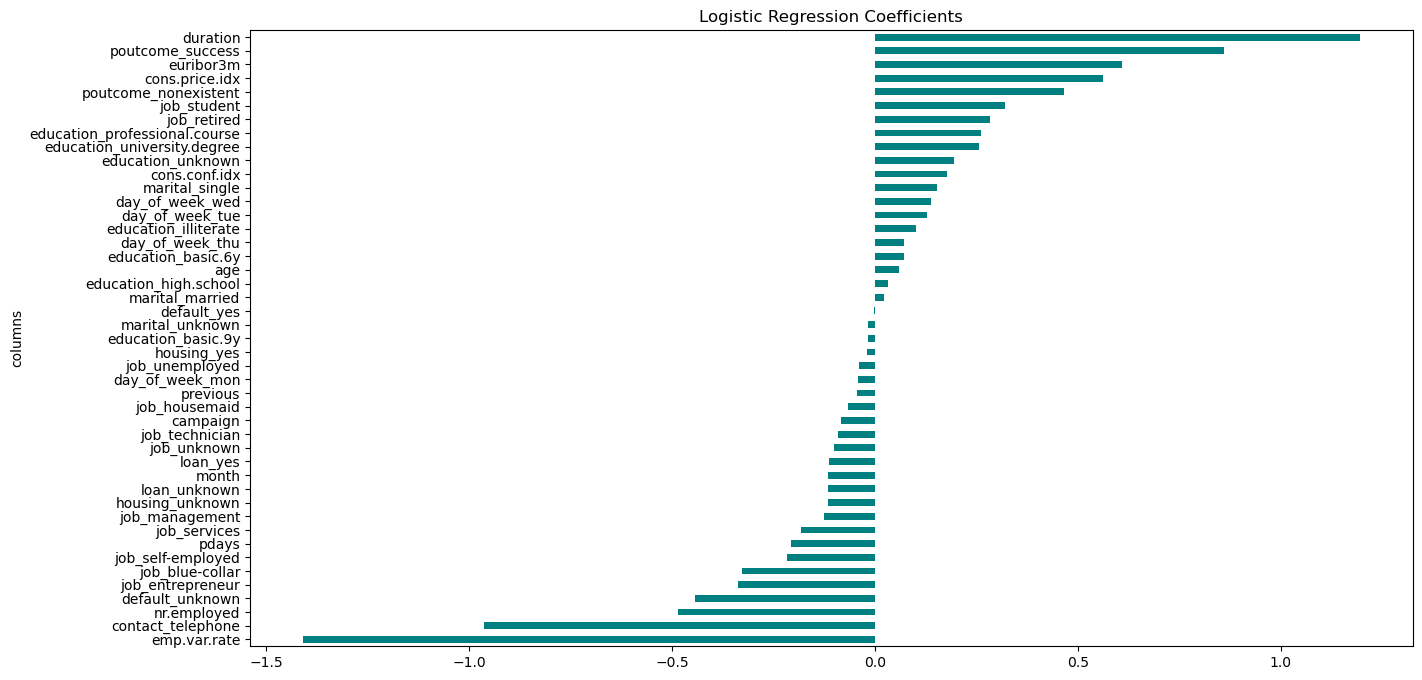

In [181]:
coefs = lr.coef_[0]

labels = X_train.columns.tolist()

lr_results = pd.DataFrame({'columns':labels, 'values':coefs, 'absolute':abs(coefs)}).sort_values(by = 'values')

lr_results.plot(kind = 'barh', x='columns', y='values', legend=False, figsize=(15,8), color='teal')
plt.title('Logistic Regression Coefficients')

plt.show()

In [182]:
lr_results.sort_values(by='absolute', ascending=False)

,columns,values,absolute
6,emp.var.rate,-1.409687,1.409687
2,duration,1.195033,1.195033
38,contact_telephone,-0.962538,0.962538
44,poutcome_success,0.859308,0.859308
9,euribor3m,0.609421,0.609421
7,cons.price.idx,0.562758,0.562758
10,nr.employed,-0.484225,0.484225
43,poutcome_nonexistent,0.466128,0.466128
32,default_unknown,-0.443414,0.443414
12,job_entrepreneur,-0.337939,0.337939


### Problem 10: Model Comparisons

Now, we aim to compare the performance of the Logistic Regression model to our KNN algorithm, Decision Tree, and SVM models.  Using the default settings for each of the models, fit and score each.  Also, be sure to compare the fit time of each of the models.  Present your findings in a `DataFrame` similar to that below:

| Model | Train Time | Train Accuracy | Test Accuracy |
| ----- | ---------- | -------------  | -----------   |
|     |    |.     |.     |

In [184]:
knn = KNeighborsClassifier()

start = time.time()
knn.fit(X_train, y_train)
knn_time = time.time() - start

In [185]:
accuracy_knn_train = knn.score(X_train, y_train)
accuracy_knn_test = knn.score(X_test, y_test)
print('The accuracy of the KNN model for Train is {:.2f}'.format(accuracy_knn_train))
print('The accuracy of the KNN model for Test is {:.2f}'.format(accuracy_knn_test))

The accuracy of the KNN model for Train is 0.93
The accuracy of the KNN model for Test is 0.90


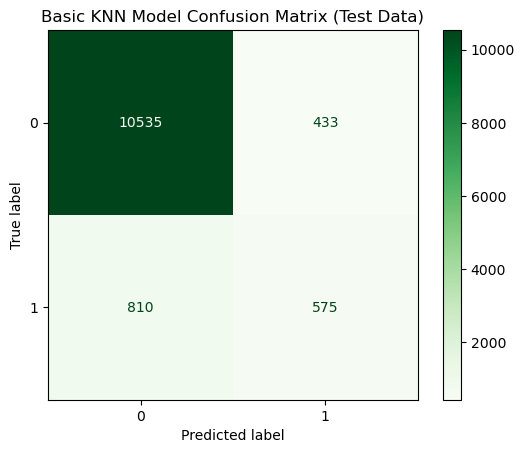

In [186]:
plot_confusion_matrix(knn, X_test, y_test, 'Basic KNN Model Confusion Matrix (Test Data)', cmap='Greens')

In [197]:
dt = DecisionTreeClassifier()


start = time.time()
dt.fit(X_train, y_train)
dt_time = time.time() - start

In [198]:
accuracy_dt_train = dt.score(X_train, y_train)
accuracy_dt_test = dt.score(X_test, y_test)
print('The accuracy of the DT model for Train is {:.2f}'.format(accuracy_dt_train))
print('The accuracy of the DT model for Test is {:.2f}'.format(accuracy_dt_test))

The accuracy of the DT model for Train is 1.00
The accuracy of the DT model for Test is 0.89


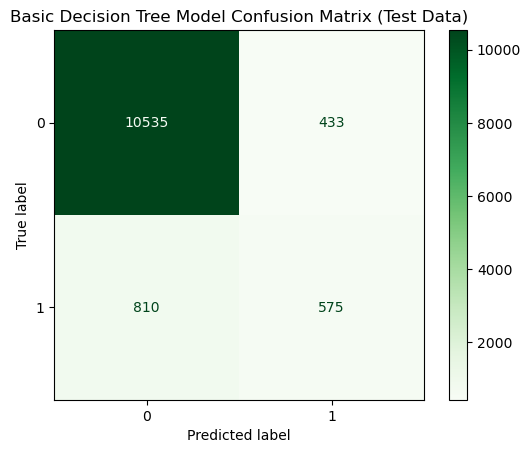

In [199]:
plot_confusion_matrix(knn, X_test, y_test, 'Basic Decision Tree Model Confusion Matrix (Test Data)', cmap='Greens')

In [188]:
rf = RandomForestClassifier()

start = time.time()
rf.fit(X_train, y_train)
rf_time = time.time() - start

In [189]:
accuracy_rf_train = rf.score(X_train, y_train)
accuracy_rf_test = rf.score(X_test, y_test)
print('The accuracy of the RF model for Train is {:.2f}'.format(accuracy_rf_train))
print('The accuracy of the RF model for Test is {:.2f}'.format(accuracy_rf_test))

The accuracy of the RF model for Train is 1.00
The accuracy of the RF model for Test is 0.91


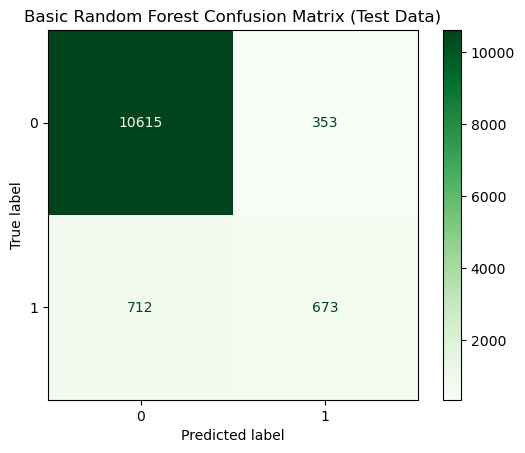

In [190]:
plot_confusion_matrix(rf, X_test, y_test, 'Basic Random Forest Confusion Matrix (Test Data)', cmap='Greens')

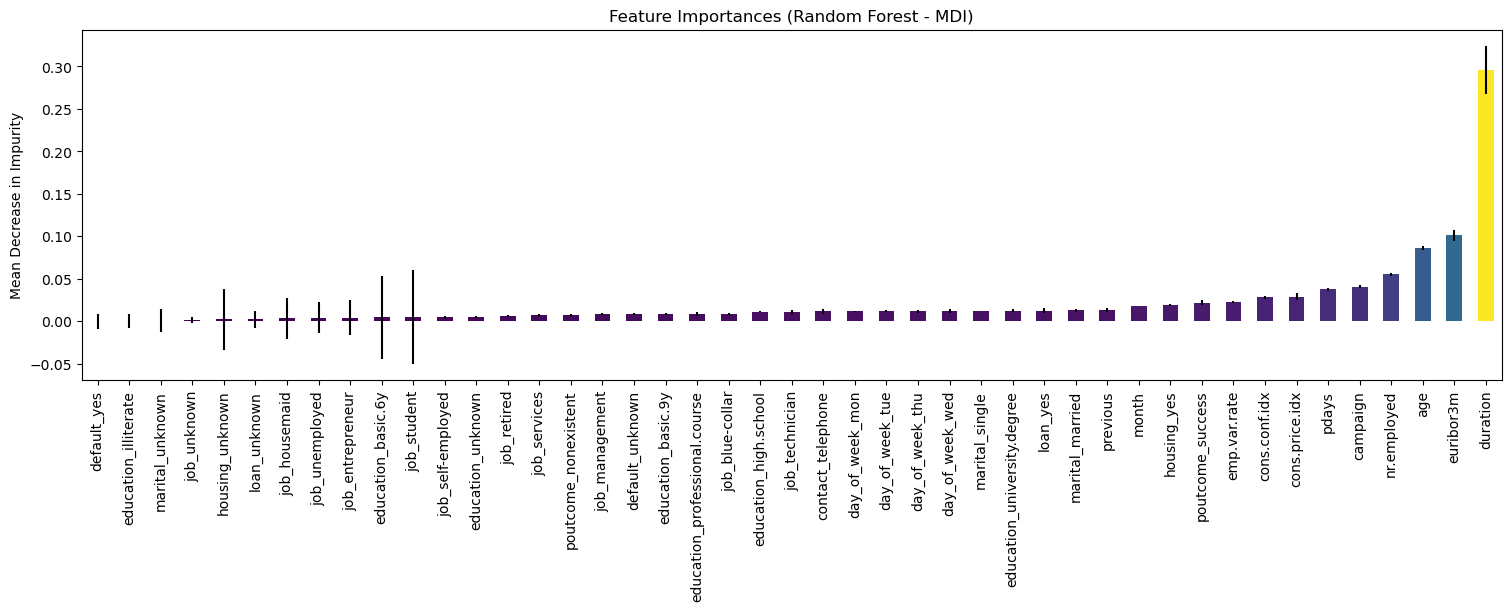

In [202]:
# Use actual column names (better than feature 0,1,2...)
feature_names = X.columns.tolist()

importances = rf.feature_importances_
std = np.std([tree.feature_importances_ for tree in rf.estimators_], axis=0)

forest_importances = pd.Series(importances, index=feature_names).sort_values(ascending=True)

colors = plt.cm.viridis(forest_importances / forest_importances.max())

fig, ax = plt.subplots(figsize=(15, 6), constrained_layout=True)

forest_importances.plot.bar(
    yerr=std,
    ax=ax,
    color=colors
)

ax.set_title("Feature Importances (Random Forest - MDI)")
ax.set_ylabel("Mean Decrease in Impurity")

plt.show()

In [192]:
svc = SVC()

start = time.time()
svc.fit(X_train, y_train)
svc_time = time.time() - start

In [193]:
accuracy_svc_train = svc.score(X_train, y_train)
accuracy_svc_test = svc.score(X_test, y_test)
print('The accuracy of the SVC model for Train is {:.2f}'.format(accuracy_svc_train))
print('The accuracy of the SVC model for Test is {:.2f}'.format(accuracy_svc_test))

The accuracy of the SVC model for Train is 0.92
The accuracy of the SVC model for Test is 0.91


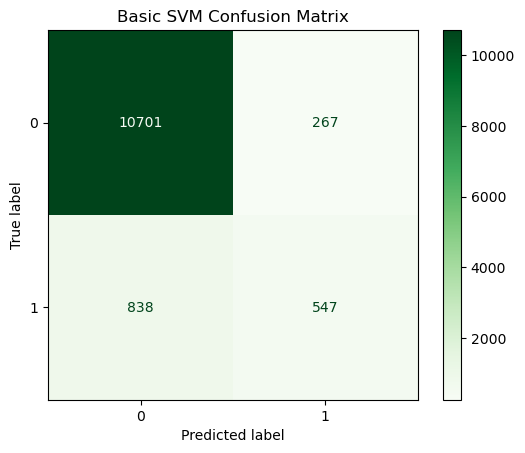

In [194]:
plot_confusion_matrix(svc, X_test, y_test, 'Basic SVM Confusion Matrix', cmap='Greens')

In [200]:
result_df = pd.DataFrame({ 
                          'Train Time':[lr_time, knn_time, dt_time, svc_time, rf_time], 
                          'Train Accuracy':[accuracy_lr_train, accuracy_knn_train, accuracy_dt_train, accuracy_svc_train, accuracy_rf_train], 
                          'Test Accuracy':[accuracy_lr_test, accuracy_knn_test, accuracy_dt_test, accuracy_svc_test, accuracy_rf_test]}, index=['Logistic Regression', 'KNN', 'Decision Tree', 'SVM', 'Random Forest'])

In [201]:
result_df

,Train Time,Train Accuracy,Test Accuracy
Logistic Regression,0.134389,0.911286,0.908767
KNN,0.170618,0.929084,0.899377
Decision Tree,0.161664,1.000000,0.890553
SVM,13.091393,0.922805,0.910548
Random Forest,2.336291,1.000000,0.913786


### Problem 11: Improving the Model

Now that we have some basic models on the board, we want to try to improve these.  Below, we list a few things to explore in this pursuit.


- Hyperparameter tuning and grid search.  All of our models have additional hyperparameters to tune and explore.  For example the number of neighbors in KNN or the maximum depth of a Decision Tree.  
- Adjust your performance metric

In [204]:
df3 = pd.get_dummies(df.drop([ 'job', 'marital', 'day_of_week', 'default', 'loan', 'cons.conf.idx','previous',
                            'poutcome', 'previous','education', 'campaign', 'housing'], axis=1), drop_first=True)
X = df3.drop(columns = 'y')
y = df3['y']

# train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=2)

to_be_scaled_columns = ['age','duration', 'emp.var.rate', 'cons.price.idx', 'pdays', 'euribor3m', 'nr.employed', 'month', ]

X_train[to_be_scaled_columns] = scaler.fit_transform(X_train[to_be_scaled_columns])
X_test[to_be_scaled_columns] = scaler.transform(X_test[to_be_scaled_columns])

dummy.fit(X_train, y_train)

print('The accuracy of the model for Train is {:.2f}'.format(dummy.score(X_train, y_train)))
print('The accuracy of the model for Test is {:.2f}'.format(dummy.score(X_test, y_test)))

The accuracy of the model for Train is 0.89
The accuracy of the model for Test is 0.89


In [206]:
lr = LogisticRegression(
    class_weight='balanced',
    fit_intercept=False,
    random_state=42,
    max_iter=1000
)

lr.fit(X_train, y_train)

print('The accuracy of the model for Train is {:.2f}'.format(lr.score(X_train, y_train)))
print('The accuracy of the model for Test is {:.2f}'.format(lr.score(X_test, y_test)))

The accuracy of the model for Train is 0.82
The accuracy of the model for Test is 0.82


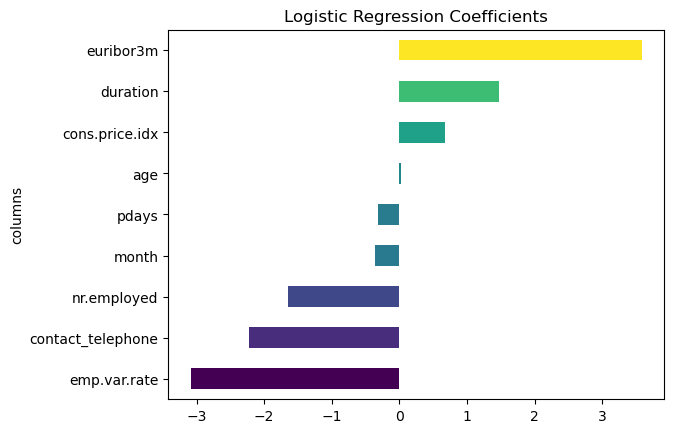

In [209]:
coefs = lr.coef_[0]

colors = plt.cm.viridis(
    (lr_results['values'] - lr_results['values'].min()) /
    (lr_results['values'].max() - lr_results['values'].min())
)

labels = X_train.columns.tolist()

lr_results = pd.DataFrame({'columns':labels, 'values':coefs}).sort_values(by = 'values')

lr_results.plot(kind = 'barh', x='columns', y='values', legend=False, color=colors)
plt.title('Logistic Regression Coefficients')

plt.show()

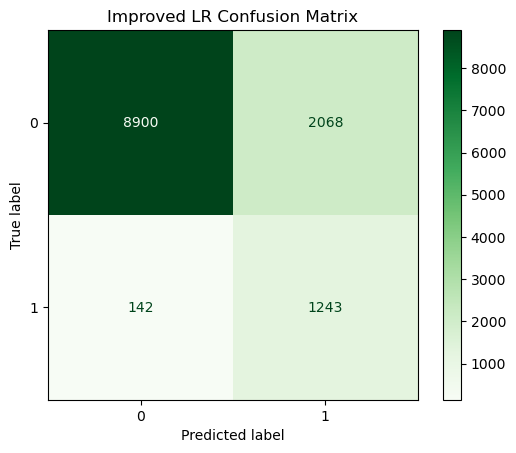

In [211]:
plot_confusion_matrix(lr, X_test, y_test, 'Improved LR Confusion Matrix', cmap='Greens')

In [212]:
print ('Accuracy of LR: ', accuracy_score(y_test, lr.predict(X_test)))
print ('Recall of LR: ', recall_score(y_test, lr.predict(X_test)))
print ('Precision of LR: ', precision_score(y_test, lr.predict(X_test)))

Accuracy of LR:  0.8210960900186189
Recall of LR:  0.8974729241877256
Precision of LR:  0.3754152823920266


In [213]:
svc = SVC(kernel='rbf', class_weight={1: 10}, random_state=42)
svc.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",{1: 10}
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


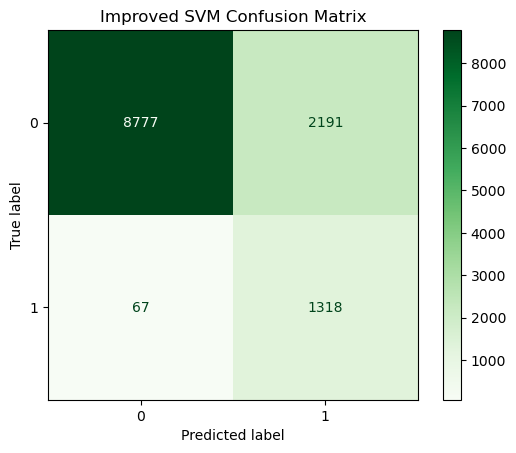

In [215]:
plot_confusion_matrix(svc, X_test, y_test, "Improved SVM Confusion Matrix", cmap='Greens')

In [216]:
print ('Accuracy of SVM: ', accuracy_score(y_test, svc.predict(X_test)))
print ('Recall of SVM: ', recall_score(y_test, svc.predict(X_test)))
print ('Precision of SVM: ', precision_score(y_test, svc.predict(X_test)))

Accuracy of SVM:  0.8172103942362179
Recall of SVM:  0.9516245487364621
Precision of SVM:  0.3756055856369336


#### Hyperparameter Tuning

In [219]:
svc = SVC(kernel="poly", class_weight={1:10}, random_state=42)

param_dict = {'kernel':['linear', 'poly', 'rbf', 'sigmoid'], 'class_weight':['balanced', {1:2}, {1:5}, {1:10}], 'degree':[1,2,3,4,5]}
    
mygrid = GridSearchCV(estimator = svc, param_grid=param_dict, scoring = 'recall')
mygrid.fit(X_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC(class_wei...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'class_weight': ['balanced', {1: 2}, ...], 'degree': [1, 2, ...], 'kernel': ['linear', 'poly', ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is

In [220]:
best_selector = mygrid.best_estimator_
best_selector

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",1
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",{1: 10}
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


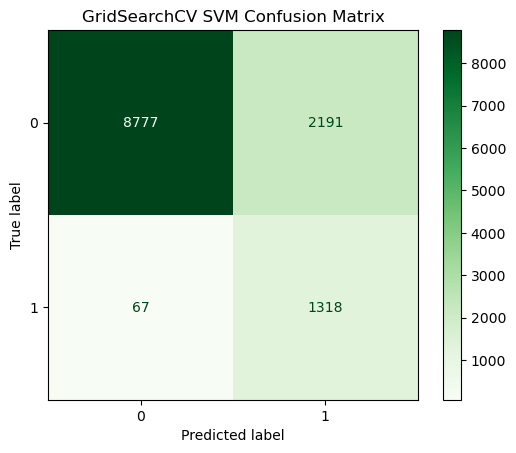

In [221]:
plot_confusion_matrix(best_selector, X_test, y_test, 'GridSearchCV SVM Confusion Matrix', cmap='Greens')

In [222]:
print ('Accuracy of GridSearchCV: ', accuracy_score(y_test, best_selector.predict(X_test)))
print ('Recall of GridSearchCV: ', recall_score(y_test, best_selector.predict(X_test)))
print ('Precision of GridSearchCV: ', precision_score(y_test, best_selector.predict(X_test)))

Accuracy of GridSearchCV:  0.8172103942362179
Recall of GridSearchCV:  0.9516245487364621
Precision of GridSearchCV:  0.3756055856369336


#### Looking at non-linear Features:

In [223]:
rf = RandomForestClassifier(class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)
print('The accuracy of the model for Train is {:.2f}'.format(rf.score(X_train, y_train)))
print('The accuracy of the model for Test is {:.2f}'.format(rf.score(X_test, y_test)))

The accuracy of the model for Train is 1.00
The accuracy of the model for Test is 0.91


In [224]:
print ('Accuracy of Improved RF: ', accuracy_score(y_test, rf.predict(X_test)))
print ('Recall of Improved RF: ', recall_score(y_test, rf.predict(X_test)))
print ('Precision of Improved RF: ', precision_score(y_test, rf.predict(X_test)))

Accuracy of Improved RF:  0.9097385250546426
Recall of Improved RF:  0.5068592057761733
Precision of Improved RF:  0.6190476190476191


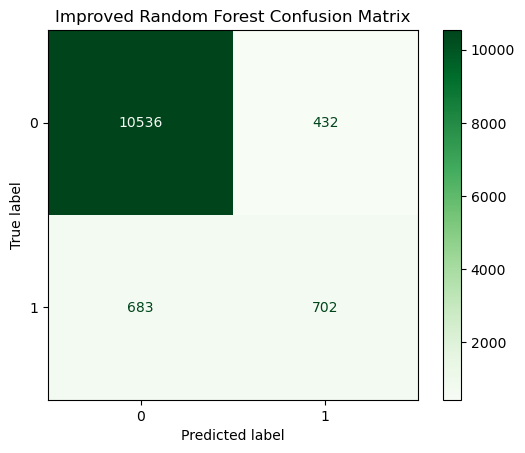

In [225]:
plot_confusion_matrix(rf, X_test, y_test, 'Improved Random Forest Confusion Matrix', cmap='Greens')

In [226]:
feature_names = [f"feature {i}" for i in X.columns.tolist()]
importances = rf.feature_importances_
std = np.std([tree.feature_importances_ for tree in rf.estimators_], axis=0)

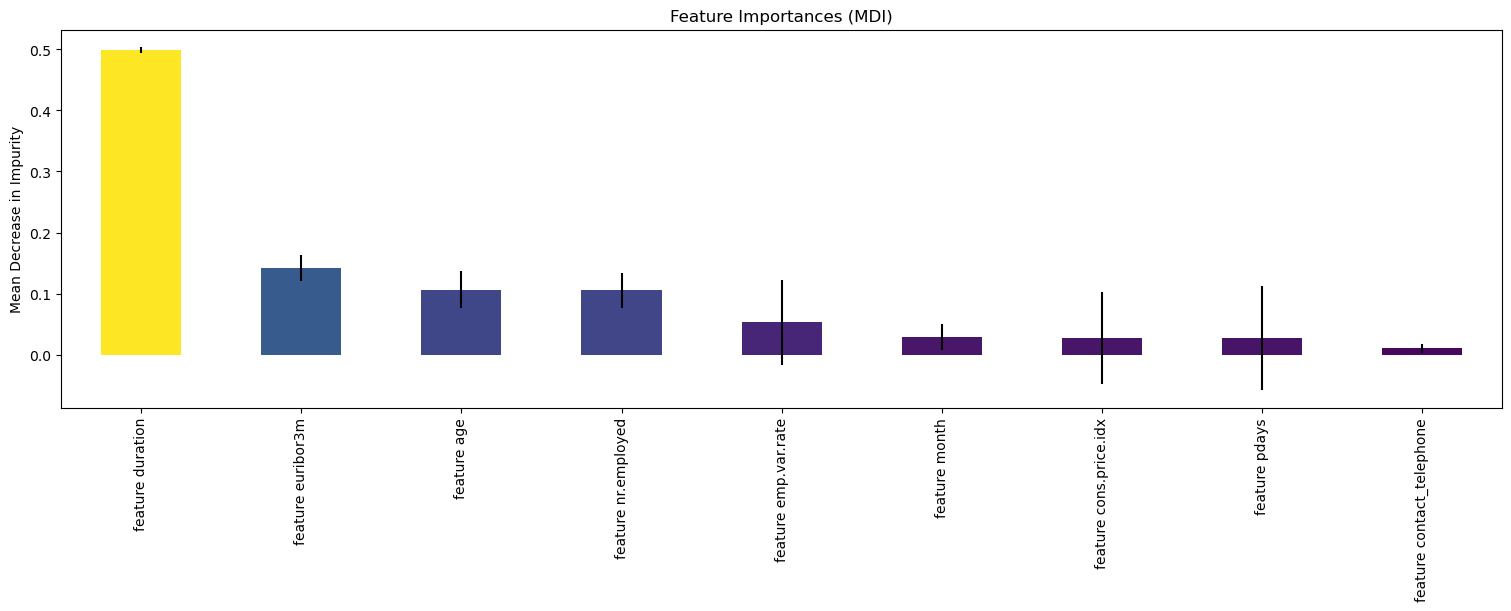

In [229]:
forest_importances = pd.Series(importances, index=feature_names)
forest_importances = forest_importances.sort_values(ascending=False)

colors = plt.cm.viridis(forest_importances / forest_importances.max())

fig, ax = plt.subplots(figsize=(15, 6), constrained_layout=True)

forest_importances.plot.bar(
    yerr=std,
    ax=ax,
    color=colors
)

ax.set_title("Feature Importances (MDI)")
ax.set_ylabel("Mean Decrease in Impurity")

plt.show()

#### ROC Curve and 80% Probability

Although this approach achieves the lowest false positive rate, it comes at the expense of overall accuracy and requires evaluating nearly half of the population. From a business perspective, this can increase operational costs, so a thorough cost–benefit analysis is necessary to determine the optimal trade-off.

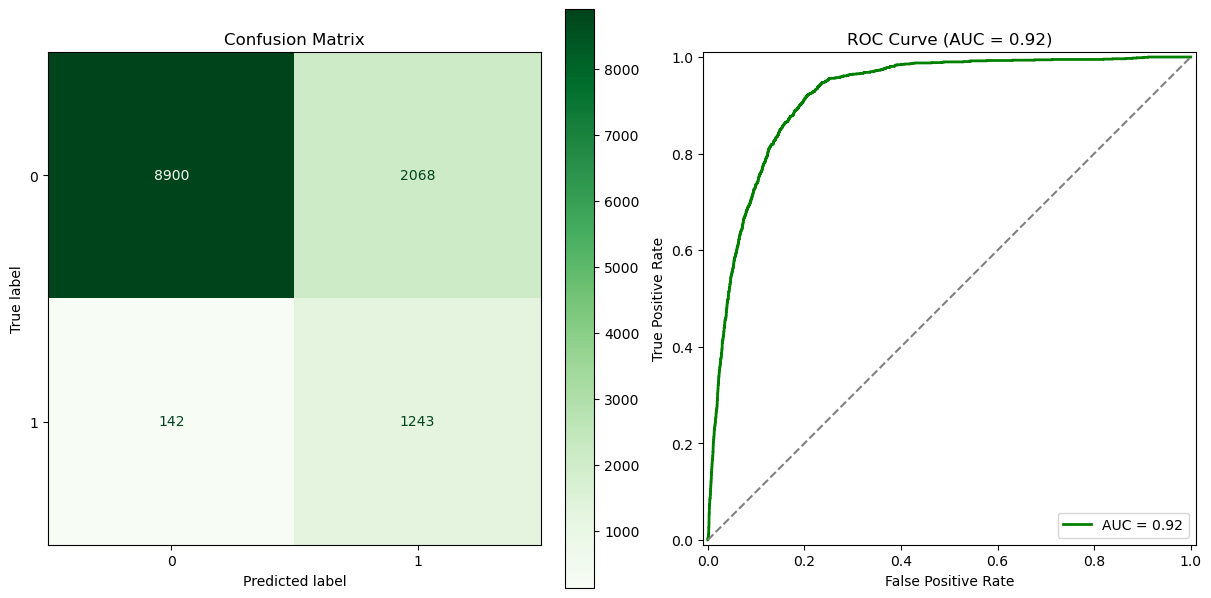

In [243]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6), constrained_layout=True)

preds = lr.predict(X_test)

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, preds)
disp1 = ConfusionMatrixDisplay(conf_matrix)
disp1.plot(ax=ax[0], cmap='Greens')
ax[0].set_title("Confusion Matrix")

# ROC Curve
y_score = lr.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_score, pos_label=1)
roc_auc_value = skl_auc(fpr, tpr)

disp2 = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc_value)
disp2.plot(ax=ax[1], curve_kwargs={'color': 'green', 'linewidth': 2})

ax[1].plot([0, 1], [0, 1], linestyle='--', color='gray')  # baseline
ax[1].set_title(f"ROC Curve (AUC = {round(roc_auc_value, 2)})")

# Metrics
fp = conf_matrix[0][1]
fn = conf_matrix[1][0]
auc = round(roc_auc_value, 2)

plt.show()

#### Questions

How much trade-off are SMEs and business analysts willing to accept between maximizing customer reach and controlling marketing costs? With the final SVM model showing a 17.7% False Positive rate and only 0.5% False Negative rate, are we over-targeting nearly 20% more customers than necessary, and is this additional cost justified or should recall be reduced?

Given the dataset is heavily imbalanced toward unsuccessful campaigns, should the model be used to identify factors driving failure, or to focus on high-potential customer segments? For example, since higher success is observed via cellular outreach, should banks shift toward modern channels like text messaging and social media to improve campaign effectiveness?

##### Questions